# Setup

In [25]:
import pickle
import networkx as nx

fb_path = "facebook_graph.pkl"
ba_path = "g_ba_model.pkl"


with open(fb_path, "rb") as f:
    G_real = pickle.load(f)
print(f" OG:")
print(f"   - V: {G_real.number_of_nodes()}")
print(f"   - E: {G_real.number_of_edges()}")



with open(ba_path, "rb") as f:
    G_rand = pickle.load(f)
print(f"\n Barabasi-Albert:")
print(f"   - V: {G_rand.number_of_nodes()}")
print(f"   - E: {G_rand.number_of_edges()}")

 OG:
   - V: 3892
   - E: 17262

 Barabasi-Albert:
   - V: 3892
   - E: 15552


# Przechodzimy na igraph bo jest lepszy >:(
##### estupido klucze bo od razu mozna wyjąć do histogramu

In [26]:
import igraph as ig
def analyze_motifs_with_igraph(G_nx):
    edges = list(G_nx.edges())
    G_ig = ig.Graph(n=G_nx.number_of_nodes(), edges=edges, directed=False)

    motifs_3 = G_ig.motifs_randesu(size=3)
    motifs_4 = G_ig.motifs_randesu(size=4)

    valid_3_motifs = {
        "Klinki (otwarte)": motifs_3[2] if motifs_3[2] is not None else 0,
        "3-Klika": motifs_3[3] if motifs_3[3] is not None else 0,
        }

    valid_4_motifs = {
        "Ścieżka 4-węzłowa": motifs_4[4] if motifs_4[4] is not None else 0,
        "Gwiazda (Star)": motifs_4[7] if motifs_4[7] is not None else 0,
        "Cykl 4-węzłowy": motifs_4[8] if motifs_4[8] is not None else 0,
        "Trójkąt z ogonkiem": motifs_4[9] if motifs_4[9] is not None else 0,
        "Kwadrat z przekątną": motifs_4[10] if motifs_4[10] is not None else 0,
        "4-Klika": motifs_4[6] if motifs_4[6] is not None else 0,
    }

    return {
        "size3": valid_3_motifs,
        "size4": valid_4_motifs,
    }

results_real = analyze_motifs_with_igraph(G_real)
results_rand = analyze_motifs_with_igraph(G_rand)

# liczby

In [27]:
import pandas as pd

raw_data = {
    "Motyw": list(results_real["size3"].keys())
    + list(results_real["size4"].keys()),
    "OG": list(results_real["size3"].values())
    + list(results_real["size4"].values()),
    "BA (Random)": list(results_rand["size3"].values())
    + list(results_rand["size4"].values()),
}

df_raw = pd.DataFrame(raw_data)

df_raw

,Motyw,OG,BA (Random)
0,Klinki (otwarte),181078,303068
1,3-Klika,87090,855
2,Ścieżka 4-węzłowa,1638359,8108869
3,Gwiazda (Star),1736741,177198
4,Cykl 4-węzłowy,35915,8469
5,Trójkąt z ogonkiem,465893,2613
6,Kwadrat z przekątną,796031,36
7,4-Klika,1606943,4881302


# Graficznie

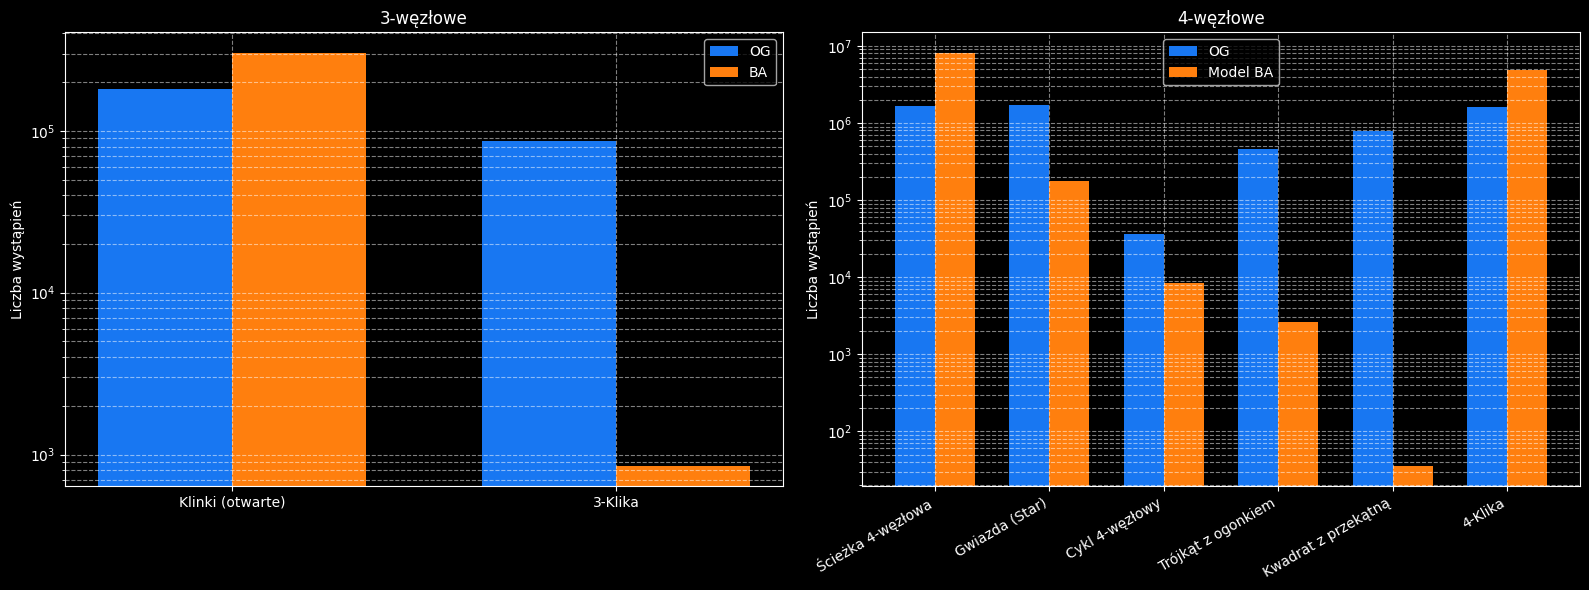

In [28]:
import matplotlib.pyplot as plt
import numpy as np

motifs_3_names = df_raw["Motyw"].iloc[:2].tolist()
real_3 = df_raw["OG"].iloc[:2].tolist()
rand_3 = df_raw["BA (Random)"].iloc[:2].tolist()

motifs_4_names = df_raw["Motyw"].iloc[2:].tolist()
real_4 = df_raw["OG"].iloc[2:].tolist()
rand_4 = df_raw["BA (Random)"].iloc[2:].tolist()

x_3 = np.arange(len(motifs_3_names))
x_4 = np.arange(len(motifs_4_names))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(x_3 - width / 2, real_3, width, label="OG", color="#1877F2")
ax1.bar(
    x_3 + width / 2,
    rand_3,
    width,
    label="BA",
    color="#FF7F0E",
)
ax1.set_title("3-węzłowe")
ax1.set_xticks(x_3)
ax1.set_xticklabels(motifs_3_names)
ax1.set_ylabel("Liczba wystąpień")
ax1.set_yscale("log")
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()


ax2.bar(x_4 - width / 2, real_4, width, label="OG", color="#1877F2")
ax2.bar(
    x_4 + width / 2,
    rand_4,
    width,
    label="Model BA",
    color="#FF7F0E",
)
ax2.set_title("4-węzłowe")
ax2.set_xticks(x_4)
ax2.set_xticklabels(motifs_4_names, rotation=30, ha="right")
ax2.set_ylabel("Liczba wystąpień")
ax2.set_yscale("log")
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

# Wnioski

# Testy statystyczne

In [29]:
import numpy as np
import scipy.stats as stats


def calculate_network_stats(df):
    real = df["OG"].to_numpy()
    rand = df["BA (Random)"].to_numpy()


    std_rand = np.where(rand > 0, np.sqrt(rand), 1.0)

    z_scores = (real - rand) / std_rand

    p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

    sp_profile = z_scores / np.sqrt(np.sum(z_scores**2))

    df_results = pd.DataFrame(
        {
            "Motyw": df["Motyw"],
            "n (OG)": real,
            "n (BA)": rand,
            "Z-score": np.round(z_scores, 2),
            "p-value": p_values,
            "SP": np.round(sp_profile, 4),
        }
    )
    return df_results, sp_profile



df_stats, sp_profile = calculate_network_stats(df_raw)
df_stats

,Motyw,n (OG),n (BA),Z-score,p-value,SP
0,Klinki (otwarte),181078,303068,-221.59,0.0,-0.0017
1,3-Klika,87090,855,2949.17,0.0,0.0222
2,Ścieżka 4-węzłowa,1638359,8108869,-2272.26,0.0,-0.0171
3,Gwiazda (Star),1736741,177198,3704.83,0.0,0.0278
4,Cykl 4-węzłowy,35915,8469,298.24,0.0,0.0022
5,Trójkąt z ogonkiem,465893,2613,9063.04,0.0,0.0681
6,Kwadrat z przekątną,796031,36,132665.83,0.0,0.9968
7,4-Klika,1606943,4881302,-1482.03,0.0,-0.0111


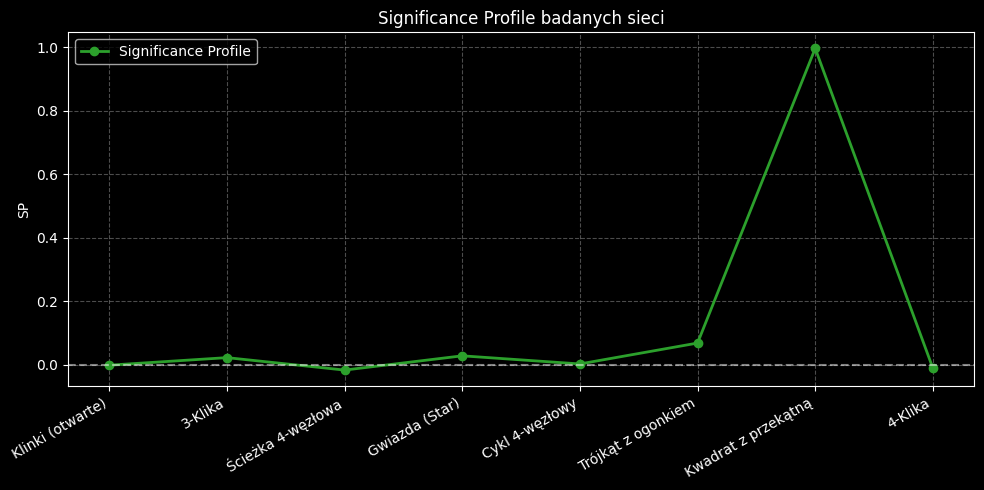

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    df_stats["Motyw"],
    sp_profile,
    marker="o",
    linewidth=2,
    color="#2CA02C",
    label="Significance Profile",
)
plt.axhline(0, color="white", linestyle="--", alpha=0.5)

plt.title("Significance Profile badanych sieci")
plt.xticks(rotation=30, ha="right")
plt.ylabel("SP")
plt.grid(True, ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Wnioski na szybko:
* W rzeczywistej oprócz silnego klastrowania w 3-Kliki mamy nawet 4-Kliki co wskazuje na istnienie grup
* Duzo gwiazd wiec duzo hubow wiec mozna wskazywac mocna hierarchicznosc

# Awarie/ataki do pieca

In [36]:
import random
G_failure = G_real.copy()
G_attack = G_real.copy()

num_nodes_to_remove = int(0.01 * G_real.number_of_nodes())

random.seed(67)
# awarie aka random delete
nodes_to_remove_random = random.sample(
    list(G_failure.nodes()), num_nodes_to_remove
)
G_failure.remove_nodes_from(nodes_to_remove_random)

# ataki aka usuwanie hubów
nodes_by_degree = sorted(G_attack.degree(), key=lambda x: x[1], reverse=True)
nodes_to_remove_attack = [node for node, deg in nodes_by_degree[:num_nodes_to_remove]]
G_attack.remove_nodes_from(nodes_to_remove_attack)

# Motywy po awariach/atakach

In [37]:
results_failure = analyze_motifs_with_igraph(G_failure)
results_attack = analyze_motifs_with_igraph(G_attack)

df_ataki = pd.DataFrame(
    {
        "Motyw": df_raw["Motyw"],
        "OG": df_raw["OG"],
        "Awarie": list(results_failure["size3"].values())
        + list(results_failure["size4"].values()),
        "Ataki": list(results_attack["size3"].values())
        + list(results_attack["size4"].values()),
    }
)


df_ataki["zmiana % awarie"] = np.round(
    (
            (df_ataki["Awarie"] - df_ataki["OG"])
            / df_ataki["OG"]
    )
    * 100,
    2,
)
df_ataki["zmiana % ataki"] = np.round(
    (
            (df_ataki["Ataki"] - df_ataki["OG"])
            / df_ataki["OG"]
    )
    * 100,
    2,
)

df_ataki

,Motyw,OG,Awarie,Ataki,zmiana % awarie,zmiana % ataki
0,Klinki (otwarte),181078,176637,108294,-2.45,-40.19
1,3-Klika,87090,86320,39363,-0.88,-54.80
2,Ścieżka 4-węzłowa,1638359,1574912,490710,-3.87,-70.05
3,Gwiazda (Star),1736741,1700298,437148,-2.10,-74.83
4,Cykl 4-węzłowy,35915,34432,22733,-4.13,-36.70
5,Trójkąt z ogonkiem,465893,459809,147606,-1.31,-68.32
6,Kwadrat z przekątną,796031,793305,156640,-0.34,-80.32
7,4-Klika,1606943,1551092,719653,-3.48,-55.22
